# LeetCode #1233: Remove Sub-Folders from the Filesystem

https://leetcode.com/problems/remove-sub-folders-from-the-filesystem/

## Comparison of Approaches

| Approach | Time Complexity | Space Complexity |
| :--- | :--- | :--- |
| **Brute Force (nested prefix check)** | $O(n^2 \cdot L)$ | $O(n)$ |
| **Optimal: Sort + Prefix Check ★** | $O(n \log n \cdot L)$ | $O(n)$ |

---

## Understanding the Methods

### Brute Force (nested prefix check)
For each folder, check whether any other folder is its ancestor by testing `f.startsWith(other + "/")`. With $n$ folders and $L$ average length this is $O(n^2 L)$ — too slow for $n = 4 \times 10^4$.

### Optimal: Sort + Prefix Check ★
Sort all folders lexicographically. After sorting, any sub-folder immediately follows its parent — checking only the previous accepted folder (`prev`) suffices. A folder is a sub-folder iff it starts with `prev + "/"`. One pass after sorting: $O(n \log n \cdot L)$ with $O(n)$ output space.

**Why this is better than Brute Force:** Sorting clusters parents before their children so a single linear scan replaces the $O(n)$ inner loop.

**Constraints:**
* $1 \le \text{folder.length} \le 4 \times 10^4$
* $2 \le \text{folder}[i]\text{.length} \le 100$
* All folders are unique and start with `/`


## Solutions

### C#

In [ ]:
public IList<string> RemoveSubfolders(string[] folder) {
    // Sorting ensures parent always appears before its children
    Array.Sort(folder);
    var result = new List<string>();
    string prev = "";
    foreach (string f in folder) {
        // Accept f only if prev is not an ancestor of f
        if (prev == "" || !f.StartsWith(prev + "/"))
        {
            result.Add(f);
            // Update the last accepted parent
            prev = f;
        }
    }
    return result;
}


### Python

In [ ]:
def remove_subfolders(folder: list[str]) -> list[str]:
    # Sorting ensures parent always appears before its children
    folder.sort()
    result = []
    prev = ""
    for f in folder:
        # Accept f only if prev is not an ancestor of f
        if not prev or not f.startswith(prev + "/"):
            result.append(f)
            # Update the last accepted parent
            prev = f
    return result


### Go

In [ ]:
func removeSubfolders(folder []string) []string {
    // Sorting ensures parent always appears before its children
    sort.Strings(folder)
    result := []string{}
    prev := ""
    for _, f := range folder {
        // Accept f only if prev is not an ancestor of f
        if prev == "" || !strings.HasPrefix(f, prev+"/") {
            result = append(result, f)
            // Update the last accepted parent
            prev = f
        }
    }
    return result
}


### Rust

In [ ]:
pub fn remove_subfolders(mut folder: Vec<String>) -> Vec<String> {
    // Sorting ensures parent always appears before its children
    folder.sort();
    let mut result = Vec::new();
    let mut prev = String::new();
    for f in &folder {
        // Accept f only if prev is not an ancestor of f
        if prev.is_empty() || !f.starts_with(&(prev.clone() + "/")) {
            result.push(f.clone());
            // Update the last accepted parent
            prev = f.clone();
        }
    }
    result
}


## Example Scenarios

**1. Common Case**
**Input:** folder = ["/a", "/a/b", "/c/d", "/c/d/e", "/c/f"]
After sort: ["/a", "/a/b", "/c/d", "/c/d/e", "/c/f"]. Scan: "/a" accepted (prev=""); "/a/b" starts with "/a/" → skip; "/c/d" accepted; "/c/d/e" starts with "/c/d/" → skip; "/c/f" doesn't start with "/c/d/" → accepted. Result: ["/a", "/c/d", "/c/f"].

**2. Slightly Complex**
**Input:** folder = ["/a", "/a/b/c", "/a/b/ca"]
After sort: ["/a", "/a/b/c", "/a/b/ca"]. Both "/a/b/c" and "/a/b/ca" start with "/a/" → both skipped. Result: ["/a"]. The `"/"` suffix in the prefix check correctly prevents "/a/b/ca" from matching "/a/b/c" as a parent.

**3. Edge Case: Time Factor**
**Input:** 40,000 folders each at depth 1 (e.g., ["/a00001", ..., "/a40000"])
No subfolder relationships. Sort takes $O(n \log n \cdot L)$; scan accepts all $n$ folders in one pass. Total $\approx 40000 \times \log(40000) \times 7 \approx 9 \times 10^6$ character comparisons.

**4. Edge Case: Space Factor**
**Input:** 40,000 folders all nested under one root ("/a", "/a/b", "/a/b/c", ...)
After sort, "/a" is accepted and all others match "/a/" → result has 1 entry. Output list is $O(1)$ size, but sort still needs $O(n)$ auxiliary space for the sort algorithm itself.

**5. Almost-Impossible but Plausible**
**Input:** folder = ["/ab", "/a"]
After sort: ["/a", "/ab"]. "/ab" does not start with "/a/" (it starts with "/a" but not "/a/") → both accepted. Result: ["/a", "/ab"]. The `+ "/"` suffix is critical: without it, "/ab" would be falsely treated as a child of "/a".


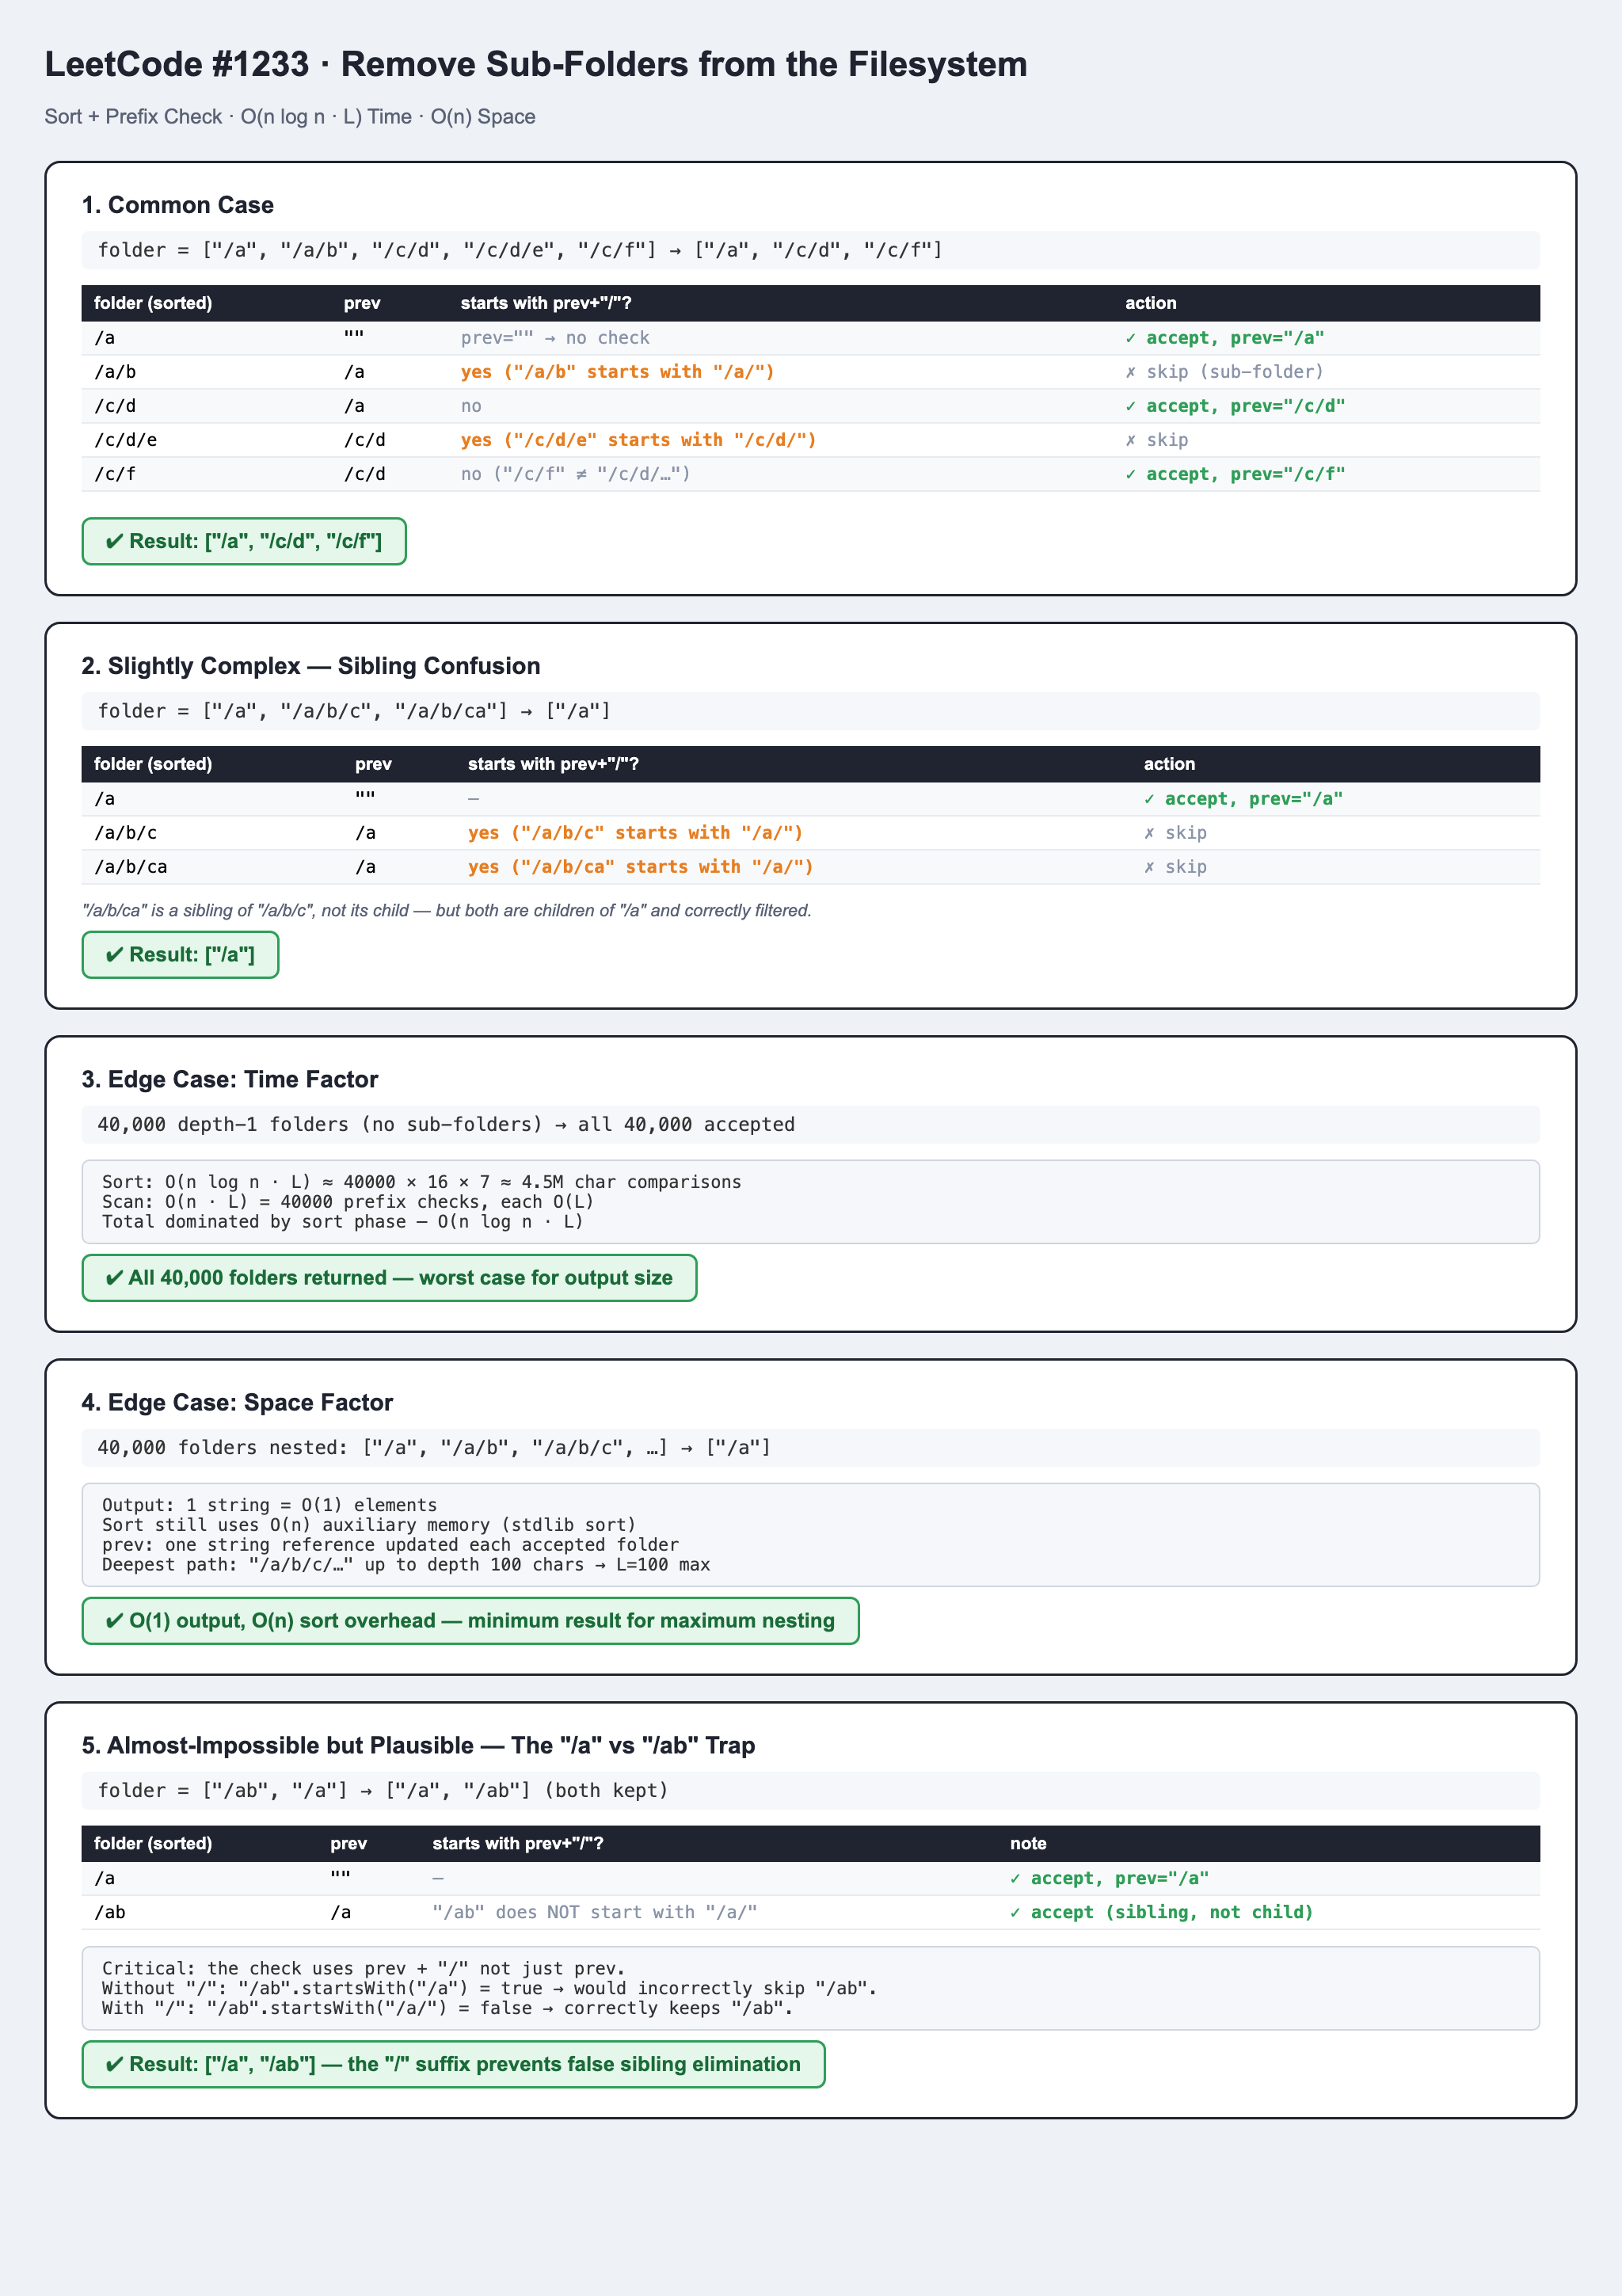